PROYECTO FINAL
TAREA 1: CLASIFICACIÓN

PREDICCIÓN DEL ÉXITO ACADÉMICO

In [256]:
#LIBRERÍAS 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#preprocesado
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.sparse import hstack

#modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#evalución
from sklearn.metrics import classification_report, confusion_matrix, f1_score
    
#split
from sklearn.model_selection import train_test_split


In [257]:
#cargamos los datos
df = pd.read_csv('rendimiento_estudiantes.csv', sep=';')

In [258]:
#vamos a hacer una exploración rápida
print(f"Shape {df.shape}")
df.info()

Shape (4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado_civil                       4424 non-null   object 
 1   modo_solicitud                     4424 non-null   object 
 2   orden_solicitud                    4424 non-null   int64  
 3   curso                              4424 non-null   object 
 4   asistencia_diurna_vespertina       4424 non-null   object 
 5   cualificacion_previa               4424 non-null   object 
 6   nota_cualificacion_previa          4424 non-null   float64
 7   nacionalidad                       4424 non-null   object 
 8   cualificacion_madre                4424 non-null   object 
 9   cualificacion_padre                4424 non-null   object 
 10  ocupacion_madre                    4424 non-null   object 
 11  ocupacion_padre                    4424

In [259]:
df["objetivo"].value_counts()



objetivo
graduado       2209
abandono       1421
matriculado     794
Name: count, dtype: int64

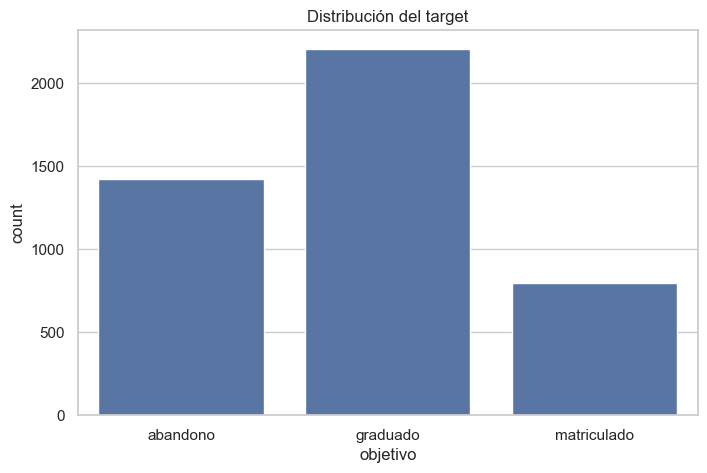

In [260]:
sns.countplot(data=df, x="objetivo")
plt.title("Distribución del target")
plt.show()

La variable objetivo del problema presenta tres clase: graduado, abandono y matriculado. A partir de esta exploración inicial, observamos una distribución claramente 
desbalanceada, siendo graduado la clase mayoritaria, seguida de abandono, mientras que matriculado representa una proporción significativamente menos del conjunto de datos

Este desbalanceo tiene varias implicaciones relevantes desde el punto de vista del modelado. En primer lugar, puede sesgar el entrenamiento de los modelos hacia la clase mayoritaria, favoreciendo predicciones de graduado. Como consecuencia, métricas globales como la accuracy podrían resultar engañosas, ya que un modelo con buen rendimiento aparente podría estar ignorando en gran medida las clases menos representadas.

En este contexto, resulta especialmente importante seleccionar métricas de evaluación adecuadas. Por ello, se opta por el uso de F1-score, ya que permite equilibrar la contribución de cada clase en función de su frecuencia, ofreciendo una evaluación más representativa del rendimiento global del modelo. Además, analizamos la matriz de confusión para estudiar en detalle los errores cometidos entre clases, lo cual es especialmente relevante en problemas multiclase como este. 

Por este motivo, no solo buscamos maximizar el rendimiento global del modelo, sino también asegurar un comportamiento razonable en las clases minoritarias. En esta línea, se incorporan técnicas como el uso de class_weight='balanced' en aquellos modelos que lo permiten, con el objetivo de penalizar más los errores en las clases menos frecuentes y mejorar su capacidad predictiva. 

In [261]:
df.dtypes.value_counts()

object     18
int64      12
float64     7
Name: count, dtype: int64

In [262]:
#vemos que claramente como son distintas magnitudes, son distintas escalas
df.describe() 

,orden_solicitud,nota_cualificacion_previa,nota_admision,edad_al_matricularse,asignaturas_1sem_convalidadas,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.727848,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,1.313793,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,0.000000,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,2.000000,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,9.000000,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


El dataset presenta una estructura mixta, con variables tanto categóricas (18) como numéricas (19), lo que refleja la diversidad de información disponible sobre los estudiantes.

Dado que los modelos de machine learning no pueden trabajar directamente con variables categóricas, aplicaremos One-Hot-Encoding para su codificaciónn. Por otro lado, las variables numéricas presentan distintas escalas, por lo que se han estandarizado mediando StandarScaler

Para gestionar correctamente ambos tipos de variable, hemos utilizado un ColumnTransformer dentro de un pipeline, permitiendo aplicar el preprocesado de forma estructurada, reproducible y sin introducir errores. 



In [263]:
"""
Eliminamos las variables del segundo semestre para evitar usar 
información futura y garantizar una predicción realista.
"""
columns_2sem = [col for col in df.columns if '_2sem' in col]
df = df.drop(columns=columns_2sem)b


SyntaxError: invalid syntax (3114283891.py, line 6)

In [ ]:
#definimos X e y
X = df.drop(columns='objetivo')
y = df['objetivo']

In [ ]:
#hacemos el split en train, validación y test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size = 0.25, random_state=42, stratify=y_temp
)

In [ ]:
#preprocesamos los datos
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categoric_cols = X.select_dtypes(include=['object']).columns

In [ ]:
#escalamos variables numéricas
scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(X_train[numeric_cols])
X_val_numeric = scaler.transform(X_val[numeric_cols])
X_test_numeric = scaler.transform(X_test[numeric_cols])

In [ ]:
#codificamos variables categóricas
encoder = OneHotEncoder(handle_unknown='ignore')

X_train_categoric = encoder.fit_transform(X_train[categoric_cols])
X_val_categoric = encoder.transform(X_val[categoric_cols])
X_test_categoric = encoder.transform(X_test[categoric_cols])

In [ ]:
#unimos todo
X_train_processed = hstack([X_train_numeric, X_train_categoric])
X_val_processed = hstack([X_val_numeric, X_val_categoric])
X_test_processed = hstack([X_test_numeric, X_test_categoric])

REGRESIÓN LOGÍSTICA

In [ ]:
#entrenamos el modelo con regresión logística
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_val_pred = model.predict(X_val_processed)

print(classification_report(y_val, y_val_pred))
print(f"F1: {f1_score(y_val, y_val_pred, average='weighted')}")

              precision    recall  f1-score   support

    abandono       0.78      0.69      0.73       284
    graduado       0.84      0.78      0.81       442
 matriculado       0.40      0.57      0.47       159

    accuracy                           0.71       885
   macro avg       0.67      0.68      0.67       885
weighted avg       0.74      0.71      0.72       885

F1: 0.7218838057971818


<Figure size 600x500 with 0 Axes>

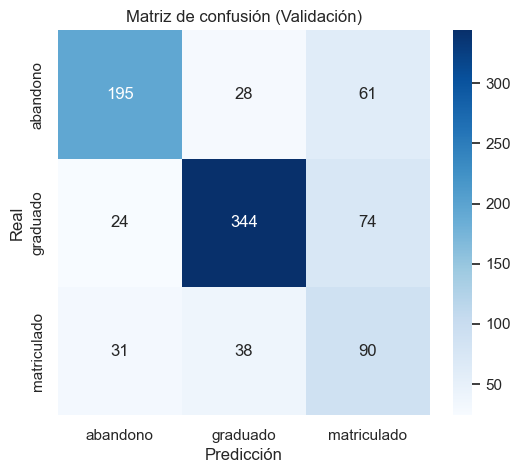

In [ ]:
#Matriz de confusión 
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6,5))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión (Validación)')
plt.show()

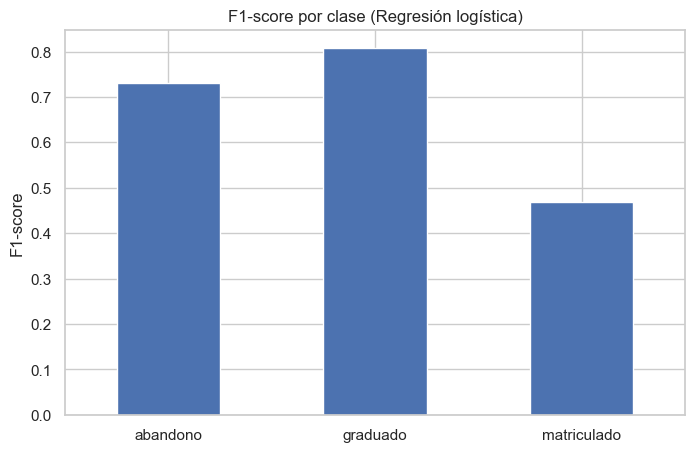

In [ ]:
#F1-Score por clase

#convertimos el report a DataFrame
report = classification_report(y_val, y_val_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

#nos quedamos solo con clases 
df_classes = df_report.iloc[:3]

#pintamos
df_classes['f1-score'].plot(kind='bar')
plt.title('F1-score por clase (Regresión logística)')
plt.ylabel('F1-score')
plt.xticks(rotation=0)
plt.show()

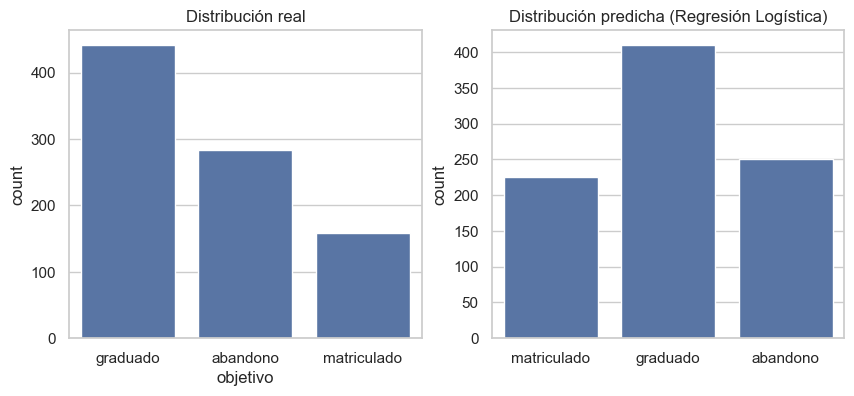

In [ ]:
#distribución real vs predicha 
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=y_val)
plt.title('Distribución real')

plt.subplot(1,2,2)
sns.countplot(x=y_val_pred)
plt.title('Distribución predicha (Regresión Logística)')

plt.show()

El modelo presenta un rendimiento global adecuado, con un F1-score ponderado de aproximadamente 0.72. Observamos que el modelo funciona especialmente bien en la clase "graduado" y, en menor medida, en "abandono", lo cual resulta positivo dado que ambas clases tienen mayor representación en el dataset.

Sin embargo, el rendimiento en la clase "matriculado" es significativamente inferior. Esto puede explicarse por el desbalanceo del dataset, ya que se trata de la clase menos frecuente, lo que dificulta que el modelo aprenda correctamente sus patrones.

En términos prácticos, esto implica que el modelo tiende a confundir a los estudiantes que continúan matriculados con otras categorías, lo cual sugiere que sería necesario mejorar la capacidad de discriminación en esta clase, por ejemplo mediante el uso de modelos más complejos o técnicas específicas para tratar el desbalanceo.

RANDOM FOREST

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
y_val_pred_rf = rf_model.predict(X_val_processed)

print(classification_report(y_val, y_val_pred_rf))
print(f"F1: {f1_score(y_val, y_val_pred_rf, average='weighted')}")

              precision    recall  f1-score   support

    abandono       0.77      0.74      0.75       284
    graduado       0.74      0.95      0.83       442
 matriculado       0.61      0.18      0.27       159

    accuracy                           0.74       885
   macro avg       0.71      0.62      0.62       885
weighted avg       0.73      0.74      0.71       885

F1: 0.705177072397746


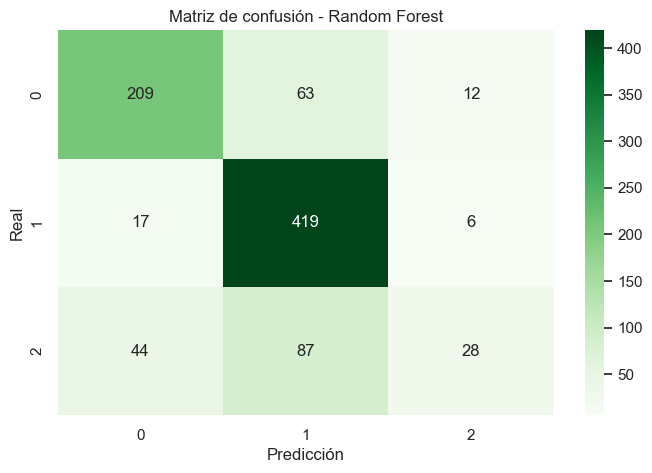

In [ ]:
#Matriz de confusión
cm = confusion_matrix(y_val, y_val_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

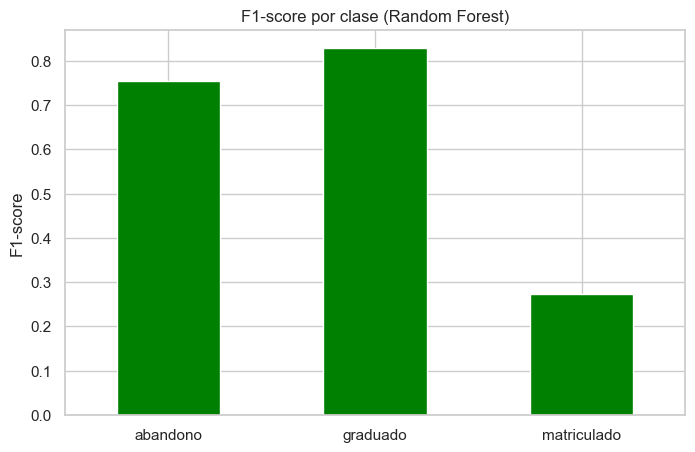

In [ ]:
#F1-Score por clase
#convertimos el report a DataFrame
report_rf = classification_report(y_val, y_val_pred_rf, output_dict=True)
df_report_rf = pd.DataFrame(report_rf).transpose()

#nos quedamos solo con clases 
df_classes_rf = df_report_rf.iloc[:3]

#pintamos
df_classes_rf['f1-score'].plot(kind='bar', color='green')

plt.title('F1-score por clase (Random Forest)')
plt.ylabel('F1-score')
plt.xticks(rotation=0)
plt.show()

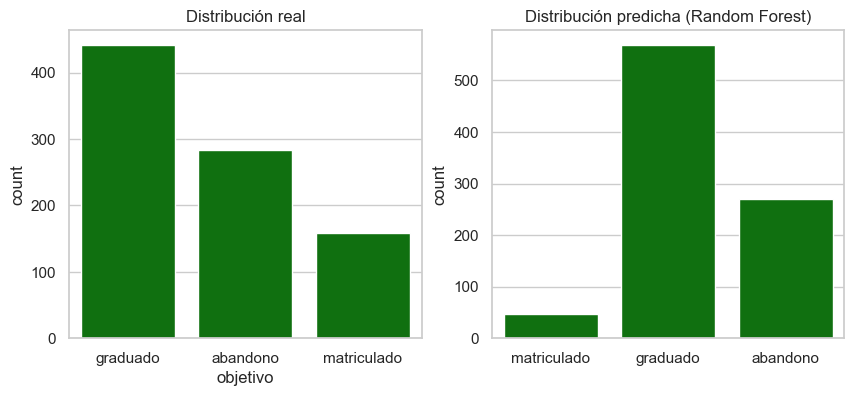

In [ ]:
#distribución real vs predicha
plt.figure(figsize=(10,4))

# Real
plt.subplot(1,2,1)
sns.countplot(x=y_val, color='green')
plt.title('Distribución real')

# Predicha
plt.subplot(1,2,2)
sns.countplot(x=y_val_pred_rf, color='green')
plt.title('Distribución predicha (Random Forest)')

plt.show()

La regresión logística presenta un comportamiento más equilibrado entre clases, especialmente en la categoría "matriculado", que es la más difícil de predecir. Por el contrario, el modelo Random Forest, aunque mantiene un rendimiento global similar, muestra una clara dificultad para identificar esta clase, con un recall significativamente bajo.

Este resultado sugiere que, en ausencia de información del segundo semestre, los modelos más complejos no necesariamente ofrecen mejores resultados, y que la regresión logística puede generalizar mejor en este escenario.

En conjunto, estos resultados ponen de manifiesto la importancia de evaluar el rendimiento por clases y no únicamente mediante métricas globales, así como la necesidad de construir modelos que sean coherentes con el objetivo predictivo del problema.

In [ ]:
#vamos a obtener la importancia de las variables
importances = rf_model.feature_importances_

#obtenemos nombres de las variables
#nombres numéricos
num_features = list(numeric_cols)

#nombres categóricos (tras OneHot)
cat_features = encoder.get_feature_names_out(categoric_cols)

#juntamos todo
feature_names = list(num_features) + list(cat_features)



feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)

feature_importance_df.head(10)

,feature,importance
7,asignaturas_1sem_aprobadas,0.095714
8,nota_media_1sem,0.086055
6,asignaturas_1sem_evaluadas,0.052499
2,nota_admision,0.045635
1,nota_cualificacion_previa,0.042648
3,edad_al_matricularse,0.041640
12,pib,0.029066
10,tasa_desempleo,0.027804
11,tasa_inflacion,0.026182
212,matricula_al_dia_no,0.025199


Observamos que las variables más importantes están relacionadas con el rendimiento en el primer semestre, especialmente las asignaturas aprobadas y la nota media. Esto indica que el desempeño académico inicial es el principal factor para predecir la trayectoria del estudiante, mientras que otras variables tienen un impacto menor.

He considerado dos enfoques: un modelo que incluye variables del segundo semestre y otro que las excluye. El modelo con variables del segundo semestre obtiene mejores resultados, ya que utiliza información más cercana al resultado final. Sin embargo, este enfoque introduce información futura, lo que limita su utilidad en un contexto predictivo real.

Por este motivo, seleccionamos como modelo final aquel que excluye las variables del segundo semestre, ya que permite realizar una predicción más realista del abandono o éxito académico a partir de información disponible en etapas iniciales.

BOOSTING

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb_model.fit(X_train_processed, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_val_pred_gb = gb_model.predict(X_val_processed)

In [ ]:
print(classification_report(y_val, y_val_pred_gb))
print("F1 GB:", f1_score(y_val, y_val_pred_gb, average="weighted"))

              precision    recall  f1-score   support

    abandono       0.77      0.75      0.76       284
    graduado       0.79      0.92      0.85       442
 matriculado       0.56      0.35      0.43       159

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885

F1 GB: 0.7465833323981422


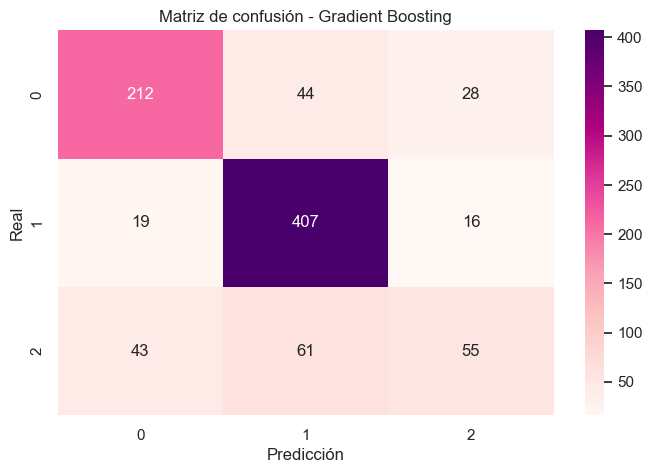

In [ ]:
#Matriz de confusión
cm = confusion_matrix(y_val, y_val_pred_gb)

sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu")  # rosa/lila
plt.title("Matriz de confusión - Gradient Boosting")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

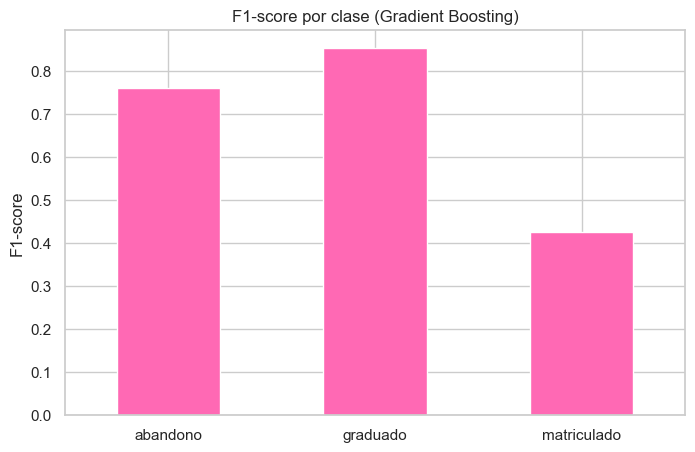

In [ ]:
#F1 por clase

report_gb = classification_report(y_val, y_val_pred_gb, output_dict=True)
df_report_gb = pd.DataFrame(report_gb).transpose()

df_classes_gb = df_report_gb.iloc[:3]

color = "#ff69b4"

df_classes_gb["f1-score"].plot(kind="bar", color=color)

plt.title("F1-score por clase (Gradient Boosting)")
plt.ylabel("F1-score")
plt.xticks(rotation=0)
plt.show()

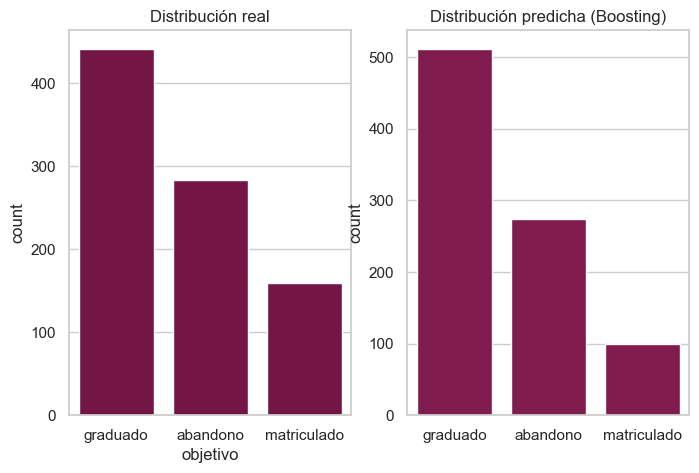

In [265]:
#distribución real vs predicha

#real
plt.subplot(1,2,1)
sns.countplot(x=y_val, color="#830645")
plt.title("Distribución real")

#predicha
plt.subplot(1,2,2)
sns.countplot(x=y_val_pred_gb, color="#910a4d")
plt.title("Distribución predicha (Boosting)")

plt.show()

Al comparar los distintos modelos en un escenario en el que hemos eliminado las variables del segundo semestre, observamos que Gradient Boosting obtiene el mejor rendimiento global, alcanzando el mayor F1-score ponderado. Esta mejora se debe principalmente a un mejor comportamiento en la clase "graduado", donde el modelo presenta una alta capacidad de acierto.

Sin embargo, el análisis por clases muestra que la regresión logística mantiene un mejor equilibrio, especialmente en la clase "matriculado", que es la más difícil de predecir. En este sentido, aunque Gradient Boosting mejora el rendimiento global, no consigue resolver completamente las dificultades asociadas a esta clase minoritaria.

En conjunto, estos resultados reflejan el compromiso entre optimizar el rendimiento global del modelo y mantener una buena capacidad de discriminación en todas las clases, especialmente en aquellas menos representadas.

Por tanto, como modelo elegimos el de boosting

In [266]:
#Boosting

#procesamos X_temp
X_temp_numeric = scaler.transform(X_temp[numeric_cols])
X_temp_categoric = encoder.transform(X_temp[categoric_cols])

X_temp_processed = hstack([X_temp_numeric, X_temp_categoric])

gb_model.fit(X_temp_processed, y_temp)

y_test_pred_gb = gb_model.predict(X_test_processed)

print(classification_report(y_test, y_test_pred_gb))
print("F1 TEST:", f1_score(y_test, y_test_pred_gb, average="weighted"))

              precision    recall  f1-score   support

    abandono       0.78      0.71      0.74       284
    graduado       0.78      0.92      0.84       442
 matriculado       0.44      0.28      0.34       159

    accuracy                           0.74       885
   macro avg       0.67      0.64      0.64       885
weighted avg       0.72      0.74      0.72       885

F1 TEST: 0.7219848566413101


Una vez seleccionado el modelo final (Gradient Boosting) y tras entrenarlo con el conjunto combinado de entrenamiento y validación, hemos evaluado su rendimiento en el conjunto de test, que se ha mantenido completamente separado durante todo el proceso.

Los resultados obtenidos muestran un F1-score ponderado en torno a 0.72, lo que indica un rendimiento consistente con el observado en validación, sugiriendo una buena capacidad de generalización del modelo.

Analizando el rendimiento por clases, observamos que el modelo identifica correctamente a los estudiantes "graduados" y, en menor medida, a los que "abandonan". Sin embargo, la clase "matriculado" continúa siendo la más difícil de predecir, presentando un rendimiento inferior, lo que puede explicarse tanto por el desbalanceo del dataset como por la mayor ambigüedad de esta categoría.

En conjunto, el modelo logra un equilibrio adecuado entre rendimiento global y coherencia metodológica, al haberse entrenado sin utilizar variables del segundo semestre, evitando así el uso de información futura y garantizando una predicción más realista.